**Nom**: Marie-Anne Randrianarivony



***Autres outils utilisés:***

1.    
```
BatchNormalization()
```
couche pour stabiliser et accélérer les réseaux de neurones profonds ainsi que de normaliser les sorties intermédiaires





2.

```
# GlobalAveragePooling2D()
```
Utilisé pour le modèle pré-entraîné ResNet50 afin de réduire le risque de sur-apprentissage.



# 2.2 Entraînement d'un classeur d'images avec un réseau de neurones convolutif en utilisant Keras





## 2.2.1. Téléchargement du code de source d'un perceptron pour le dataset "Fashion_MNIST"

In [37]:
# Importation des modules nécessaires
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras # Les versions récentes de TensorFlow ont été changé, tensorflow.keras devient un package séparé.
from keras import layers, models
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator # ImageDataGenerator déplacé dans les nouvelles versions de Keras
from tensorflow.keras.applications import VGG16
from keras.models import Model
import time
import random
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.applications import ResNet50


In [38]:
# importation du module Keras
from tensorflow import keras

In [40]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [41]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

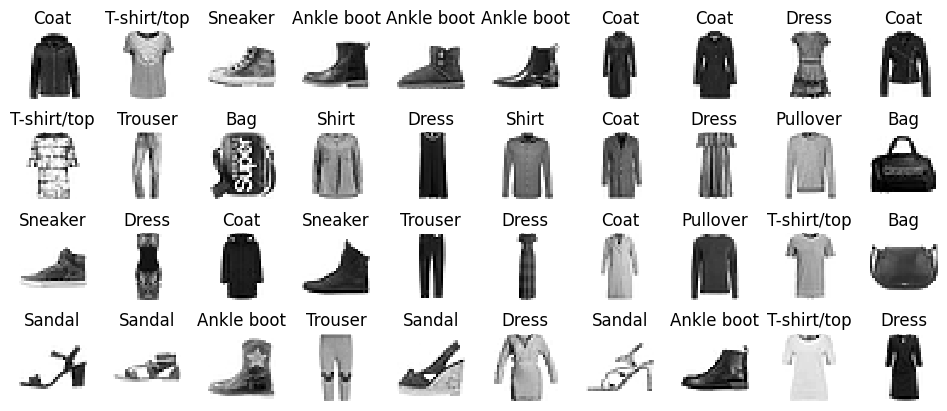

In [42]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
  for col in range(n_cols):
    index = n_cols * row + col
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()


In [43]:
keras.backend.clear_session() # Ré-initialiser les états internes de tensorflow
np.random.seed(42)
tf.random.set_seed(42)

In [44]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])


In [47]:
start = time.time()
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))
pmc_time = time.time() - start

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7633 - loss: 0.7226 - val_accuracy: 0.8198 - val_loss: 0.5229
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8279 - loss: 0.4906 - val_accuracy: 0.8440 - val_loss: 0.4566
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8444 - loss: 0.4438 - val_accuracy: 0.8556 - val_loss: 0.4221
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8550 - loss: 0.4152 - val_accuracy: 0.8608 - val_loss: 0.4019
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8624 - loss: 0.3946 - val_accuracy: 0.8666 - val_loss: 0.3874
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8677 - loss: 0.3783 - val_accuracy: 0.8700 - val_loss: 0.3753
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8713 - loss: 0.3646 - val_accuracy: 0.8726 - val_loss: 0.3651
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8752 - loss: 0.3529 - 

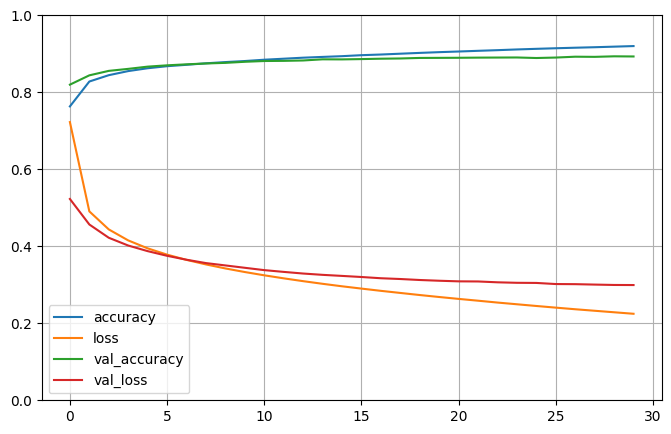

In [48]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [49]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8811 - loss: 0.3395


[0.33947327733039856, 0.8810999989509583]

## 2.2.2. Implantation d'un CNN avec une architecture à déterminer, qui améliore la performance du modèle obtenu en 2.2.1

In [50]:
# Pour garantir des résultats reproductibles
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [51]:
# Chargement des données
(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = fashion_mnist.load_data()
x_train_cnn = x_train_cnn.reshape((-1,28,28,1)).astype('float32') / 255
x_test_cnn = x_test_cnn.reshape((-1,28,28,1)).astype('float32') / 255
y_train_cat = to_categorical(y_train_cnn)
y_test_cat = to_categorical(y_test_cnn)

In [52]:
# Sélection d'un jeu de validation
x_val = x_train_cnn[:5000]
y_val = y_train_cat[:5000]
x_train_final = x_train_cnn[5000:]
y_train_final = y_train_cat[5000:]

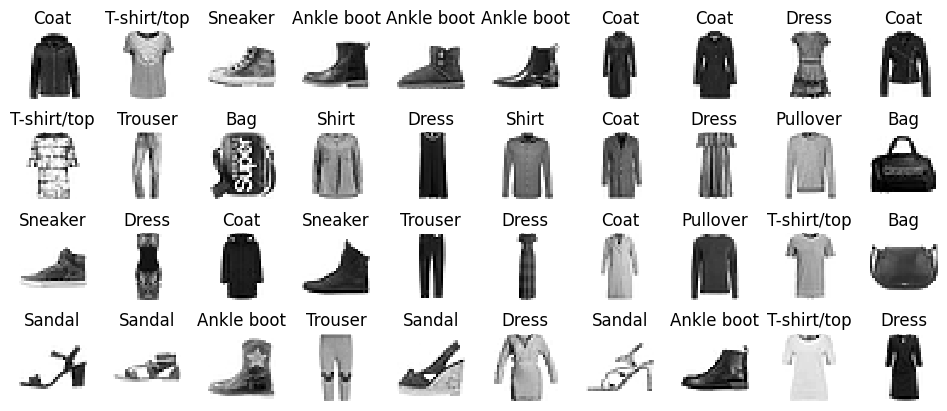

In [53]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
  for col in range(n_cols):
    index = n_cols * row + col
    plt.subplot(n_rows, n_cols, index + 1)
    plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [54]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.6),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
optimizer = Adam(learning_rate=0.0003)
cnn_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])



start = time.time()
cnn_history = cnn_model.fit(x_train_final, y_train_final, epochs=20, batch_size=64, validation_data=(x_val, y_val), verbose=1)
cnn_time = time.time() - start

Epoch 1/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9232 - loss: 0.2139 - val_accuracy: 0.9208 - val_loss: 0.2111
Epoch 2/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9255 - loss: 0.2074 - val_accuracy: 0.9268 - val_loss: 0.1918
Epoch 3/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9293 - loss: 0.1998 - val_accuracy: 0.9306 - val_loss: 0.1849
Epoch 4/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9300 - loss: 0.1945 - val_accuracy: 0.9312 - val_loss: 0.1856
Epoch 5/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9325 - loss: 0.1882 - val_accuracy: 0.9224 - val_loss: 0.2057
Epoch 6/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9335 - loss: 0.1856 - val_accuracy: 0.9334 - val_loss: 0.1836
Epoch 7/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9341 - loss: 0.1838 - val_accuracy: 0.9288 - val_loss: 0.1930
Epoch 8/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9345 - loss: 0.1804 - val_accuracy:

In [63]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,752 (2.27 MB)

 Trainable params: 198,058 (773.66 KB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 396,118 (1.51 MB)

In [64]:
cnn_model_evaluate = cnn_model.evaluate(x_test_cnn, y_test_cat)
cnn_model_evaluate

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9286 - loss: 0.2166


[0.2166479527950287, 0.928600013256073]

Avec le modèle de base dans la section 2.2.1, on a eu une exactitude du jeu de validation de **88%**. Ce qui est loin comparé à celle du jeu d'entraînement qui est de **91.95%**.

Après amélioration sur le modèle, on obtient **92%** sur le jeu de validation ce qui se rapproche fortement de l'exactitude du jeu d'entraînement à **94%**.


## 2.2.3. Courbe d'apprentissage du CNN, analyse de son comportement en s'appuyant sur la courbe de performance

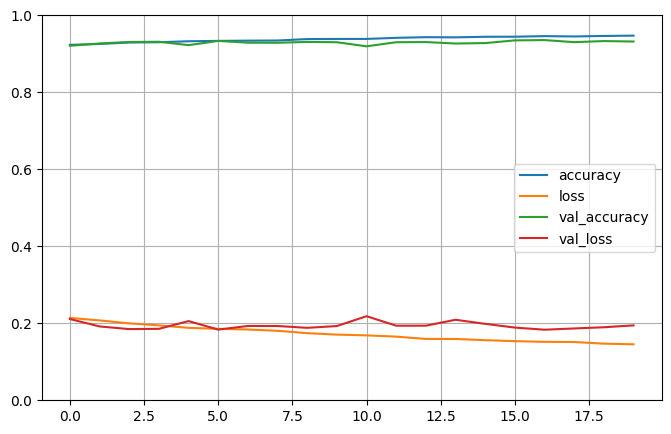

In [65]:
pd.DataFrame(cnn_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

On observe une bonne performance, le modèle généralise bien. L'exactitude pour le jeu d'entraînement et le jeu de test est **quasi équivalent**. On observe **aucun écart significatif** sur la courbe d'exactitude (bleue) et la courbe de validation (vert).

##

## 2.2.4. Entraînement du CNN en 2.2.2. en utilisant la technique d'augmentation des données à l'aide de l'outil "Image DataGenerator" de Keras

In [66]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train_cnn)

cnn_modele_augmente = tf.keras.models.clone_model(cnn_model)
cnn_modele_augmente.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
cnn_history_augmente = cnn_modele_augmente.fit(datagen.flow(x_train_cnn, y_train_cat, batch_size=128),
                                               epochs=20, validation_data=(x_test_cnn, y_test_cat), verbose=1)
cnn_time_augmente = time.time() - start

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.6909 - loss: 0.8778 - val_accuracy: 0.6641 - val_loss: 0.8890
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - accuracy: 0.7941 - loss: 0.5622 - val_accuracy: 0.8260 - val_loss: 0.4398
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.8192 - loss: 0.4930 - val_accuracy: 0.8699 - val_loss: 0.3518
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.8359 - loss: 0.4523 - val_accuracy: 0.8784 - val_loss: 0.3358
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.8477 - loss: 0.4256 - val_accuracy: 0.8900 - val_loss: 0.3135
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8534 - loss: 0.4014 - val_accuracy: 0.8618 - val_loss: 0.3542
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8612 - loss: 0.3838 - val_accuracy: 0.8436 - val_loss: 0.3888
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.8645 - loss: 0.3758 - 

In [25]:
cnn_modele_augmente.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,752 (2.27 MB)

 Trainable params: 198,058 (773.66 KB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 396,118 (1.51 MB)

In [26]:
cnn_modele_augmente.evaluate(x_test_cnn, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8966 - loss: 0.2714


[0.2714417278766632, 0.8966000080108643]

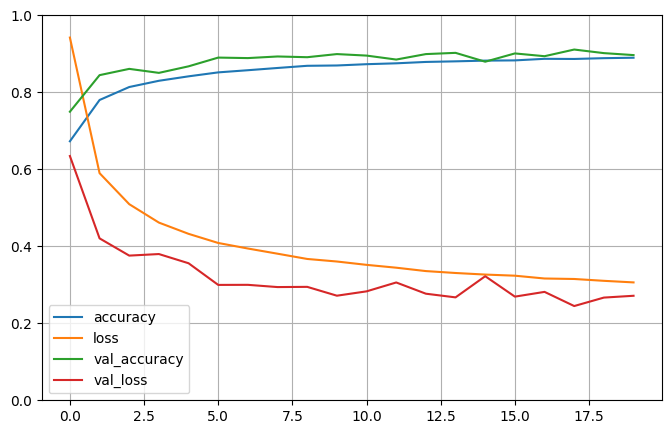

In [27]:
pd.DataFrame(cnn_history_augmente.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Après avoir augmenter les données, le modèle généralise plutôt bien étant donné que l'exactitude obtenu pour le jeu de validation **89,66%** est presque équivalent à celle du jeu d'entraînement **89%**. Néanmoins, la performance du modèle a diminué comparé au modèle vu au section 2.2.3.

## 2.2.5. Utilisation d'un modèle pré-entrainé VGG16, pour tenter d'augmenter la performance du CNN obtenu en 2.2.4 ; Tracer sa courbe de performance

In [67]:

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48,3))

# Redimensionnement
x_train_vgg = tf.image.resize(tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_train_cnn)), [48,48])
x_test_vgg = tf.image.resize(tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_test_cnn)), [48,48])

# Encodage des étiquettes
y_train_cat = to_categorical(y_train_cnn)


print(x_train_vgg.shape, y_train_cat.shape)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 48, 48, 3) (60000, 10)


In [68]:
vgg_model = models.Sequential([
vgg_base,
layers.Flatten(),
layers.Dense(256, activation='relu'),
layers.BatchNormalization(),
layers.Dense(10, activation='softmax')
])

vgg_base.trainable = False

vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
vgg_history = vgg_model.fit(x_train_vgg, y_train_cat, epochs=15, batch_size=128, validation_data=(x_test_vgg, y_test_cat), verbose=1)
vgg_time = time.time() - start

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.8365 - loss: 0.4625 - val_accuracy: 0.8447 - val_loss: 0.4293
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.8719 - loss: 0.3567 - val_accuracy: 0.8503 - val_loss: 0.4118
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.8802 - loss: 0.3313 - val_accuracy: 0.8520 - val_loss: 0.4159
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.8869 - loss: 0.3130 - val_accuracy: 0.8613 - val_loss: 0.3946
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.8920 - loss: 0.2978 - val_accuracy: 0.8653 - val_loss: 0.3732
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.8953 - loss: 0.2850 - val_accuracy: 0.8692 - val_loss: 0.3734
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9010 - loss: 0.2718 - val_accuracy: 0.8662 - val_loss: 0.3794
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9026 - loss: 0.2656 - 

In [69]:
vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,118,432 (57.67 MB)

 Trainable params: 134,410 (525.04 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

 Optimizer params: 268,822 (1.03 MB)

In [73]:
vgg_model.evaluate(x_test_vgg, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8598 - loss: 0.4348


[0.4348272979259491, 0.8597999811172485]

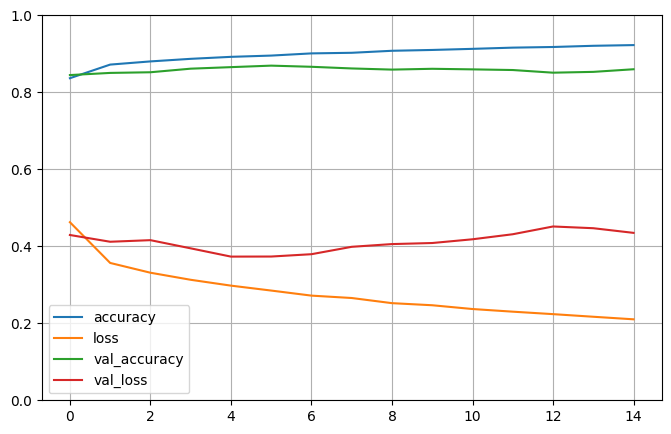

In [74]:
pd.DataFrame(vgg_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()


En utilisant un modèle pré-entrainé, le modèle **généralise bien** avec un **léger écart** entre la courbe d'apprentissage et la courbe de test.

## 2.2.6. Étude comparative entre 4 modèles (modèle pré-entrainé, CNN avec augmentation des données, CNN sans augmentation des données, PMC-Keras, en s'appuyant sur l'accuracy, le temps d'entraînement moyennant le GPU.

In [75]:
print("\nComparaison des modèles")
print(f"PMC: {history.history['val_accuracy'][-1]*100:.2f}% - Temps: {pmc_time:.2f} sec")
print(f"CNN: {cnn_history.history['val_accuracy'][-1]*100:.2f}% - Temps: {cnn_time:.2f} sec")
print(f"CNN + Augmentation: {cnn_history_augmente.history['val_accuracy'][-1]*100:.2f}% - Temps: {cnn_time_augmente:.2f} sec")
print(f"ResNet50: {vgg_history.history['val_accuracy'][-1]*100:.2f}% - Temps: {res_time:.2f} sec")


Comparaison des modèles
PMC: 89.30% - Temps: 139.16 sec
CNN: 93.18% - Temps: 114.32 sec
CNN + Augmentation: 90.75% - Temps: 524.32 sec
ResNet50: 85.98% - Temps: 126.59 sec


En se basant sur l'exactitude des données de test et le temps d'exécution comme paramètre pour chaque modèle, on peut constater que modèle CNN de la section 2.2.2 est le plus performant avec un accuracy de **93.18%** et avec un temps d'exécution de **114.32 sec** plus faible que le modèle CNN avec augmentation des données de **524.32 sec**.
